In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc

import pandas as pd

from Functions import *

### Plotting Indicators

In [2]:
def plot_candlesticks(df, df_with_mfi, df_with_rsi, symbol: str, period=14):

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2]})

    # Prepare data for candlestick
    quotes = []
    for idx, (multi_idx, row) in enumerate(df.iterrows()):
        timestamp = multi_idx
        quotes.append((
            mdates.date2num(timestamp),
            row['open'],
            row['high'],
            row['low'],
            row['close']
        ))

    # Candlestick chart
    candlestick_ohlc(ax1, quotes, width=0.6, colorup='g', colordown='r', alpha=0.8)
    ax1.set_title(f'{symbol} Candlestick Chart')
    ax1.set_ylabel('Price')
    ax1.grid(True)

    # MFI chart
    dates = [multi_idx for multi_idx in df_with_mfi.index]
    ax2.plot(dates, df_with_mfi['mfi'], color='purple', linewidth=1.5)
    # Overbought 
    ax2.axhline(y=80, color='r', linestyle='--', alpha=0.5)
    ax2.axhline(y=20, color='g', linestyle='--', alpha=0.5)

    # Oversold
    ax2.fill_between(dates, df_with_mfi['mfi'], 80, where=(df_with_mfi['mfi'] >= 80), color='r', alpha=0.3)
    ax2.fill_between(dates, df_with_mfi['mfi'], 20, where=(df_with_mfi['mfi'] <= 20), color='g', alpha=0.3)

    ax2.set_ylabel('MFI')
    ax2.set_ylim(0, 100)
    ax2.grid(True)

    # Plot RSI
    dates = [multi_idx for multi_idx in df_with_rsi.index]
    ax3.plot(dates, df_with_rsi['rsi'], color='blue', linewidth=1.5)
    ax3.axhline(y=70, color='r', linestyle='--', alpha=0.5)  # Overbought line
    ax3.axhline(y=30, color='g', linestyle='--', alpha=0.5)  # Oversold line
    
    # Highlight overbought/oversold regions
    ax3.fill_between(dates, df_with_rsi['rsi'], 70, where=(df_with_rsi['rsi'] >= 70), 
                    color='r', alpha=0.3)  # Highlight overbought
    ax3.fill_between(dates, df_with_rsi['rsi'], 30, where=(df_with_rsi['rsi'] <= 30), 
                    color='g', alpha=0.3)  # Highlight oversold
    
    ax3.set_ylabel('RSI')
    ax3.set_ylim(0, 100)
    ax3.grid(True)

    # Format x-axis with dates
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


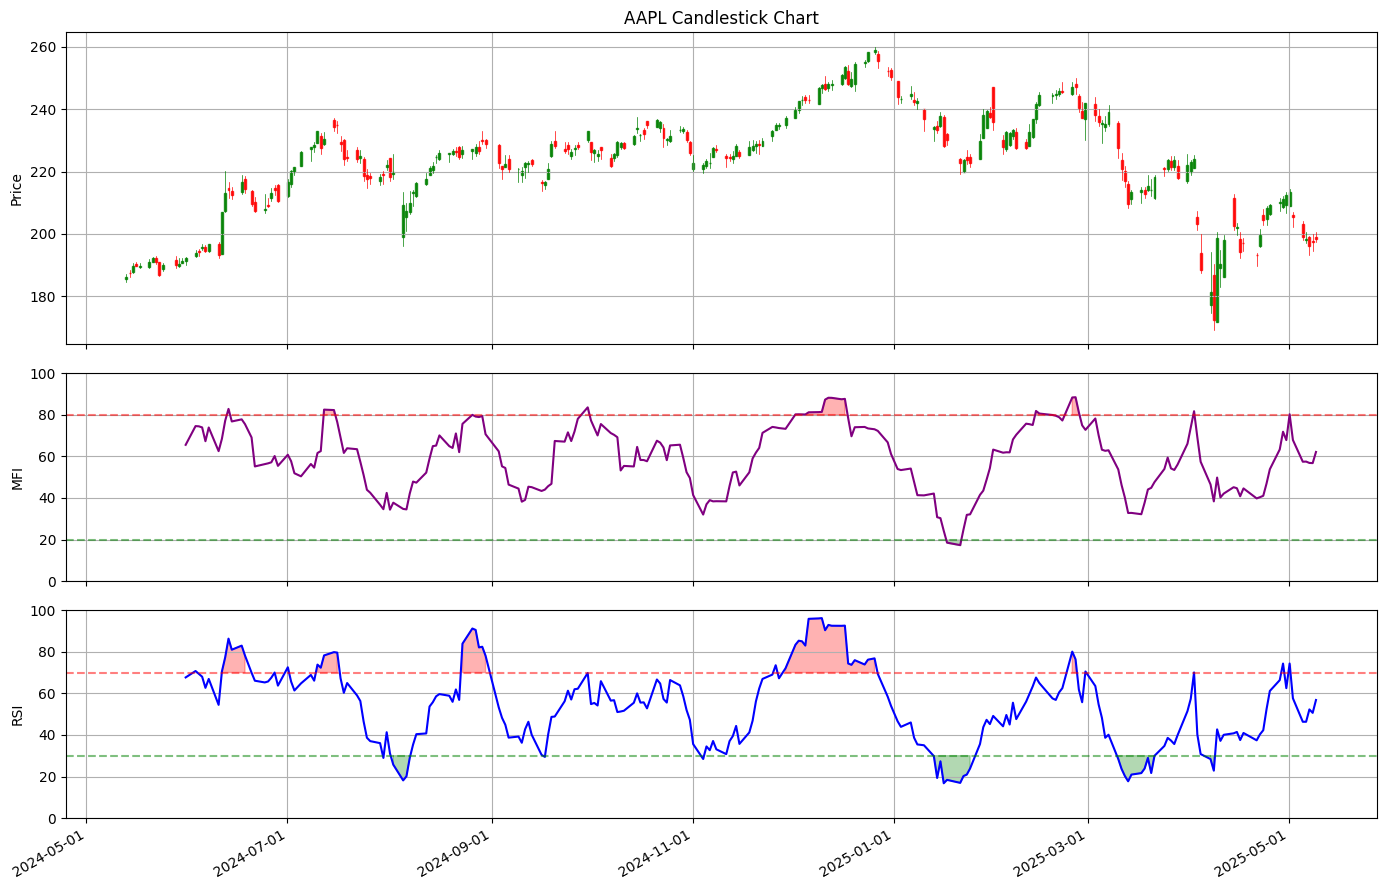

In [3]:
# Example usage
symbol = "AAPL"
start_date = "2024-05-12"
end_date = "2025-05-12"
timeframe_unit = "Day"  # "Day", "Minute", "Hour"
multiplier = 1
# Get stock data
df = get_stock_data(symbol, start_date, end_date, timeframe_unit, multiplier)

# Calculate MFI
df_with_mfi = calculate_mfi(df)

# Calculate RSI
df_with_rsi = calculate_rsi(df)

# Plot candlestick chart with volume
plot_candlesticks(df, df_with_mfi, df_with_rsi, symbol)

### Plotting Equity

In [4]:
def plot_equity_curve(equity_rsi, equity_mfi, equity_combined):
    plt.figure(figsize=(15, 6))
    plt.plot(equity_rsi, label='Equity Curve', linewidth=2)
    plt.title("RSI Strategy Equity Curve")
    plt.xlabel("Time")
    plt.ylabel("Cash / Equity")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 6))
    plt.plot(equity_mfi, label='Equity Curve', linewidth=2)
    plt.title("MFI Strategy Equity Curve")
    plt.xlabel("Time")
    plt.ylabel("Cash / Equity")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 6))
    plt.plot(equity_combined, label='Equity Curve', linewidth=2)
    plt.title("COMBINED Strategy Equity Curve")
    plt.xlabel("Time")
    plt.ylabel("Cash / Equity")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

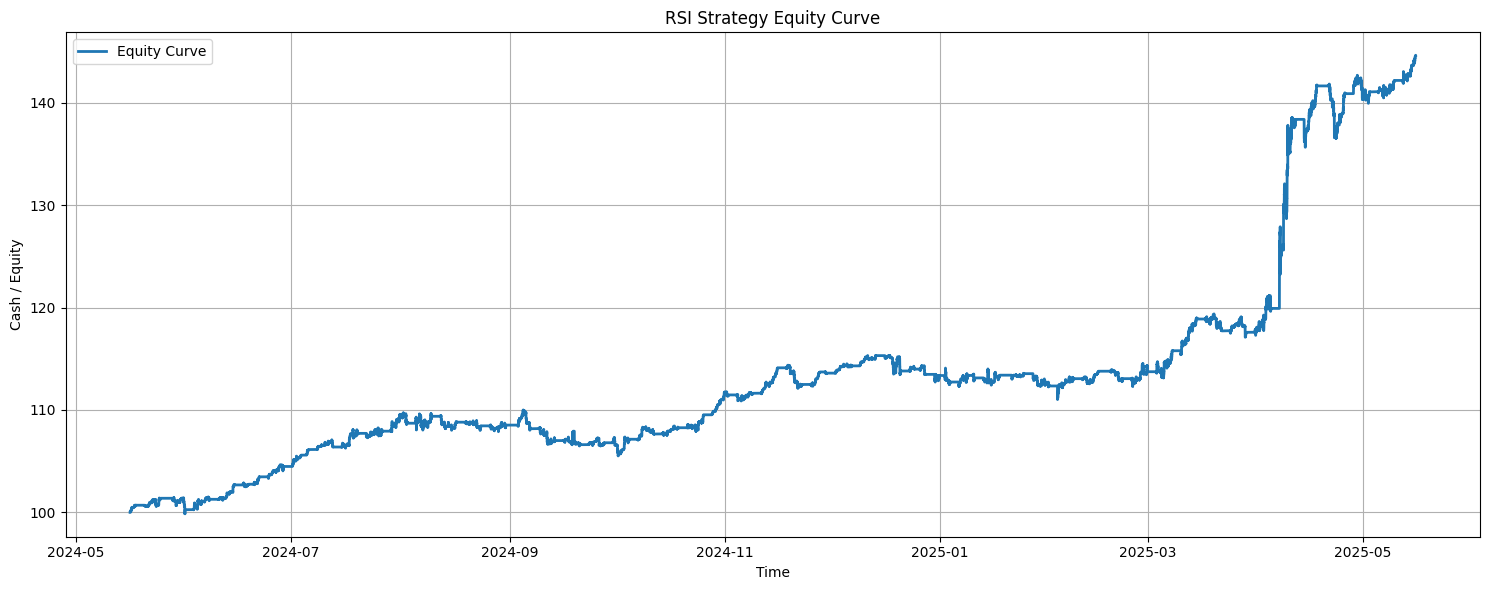

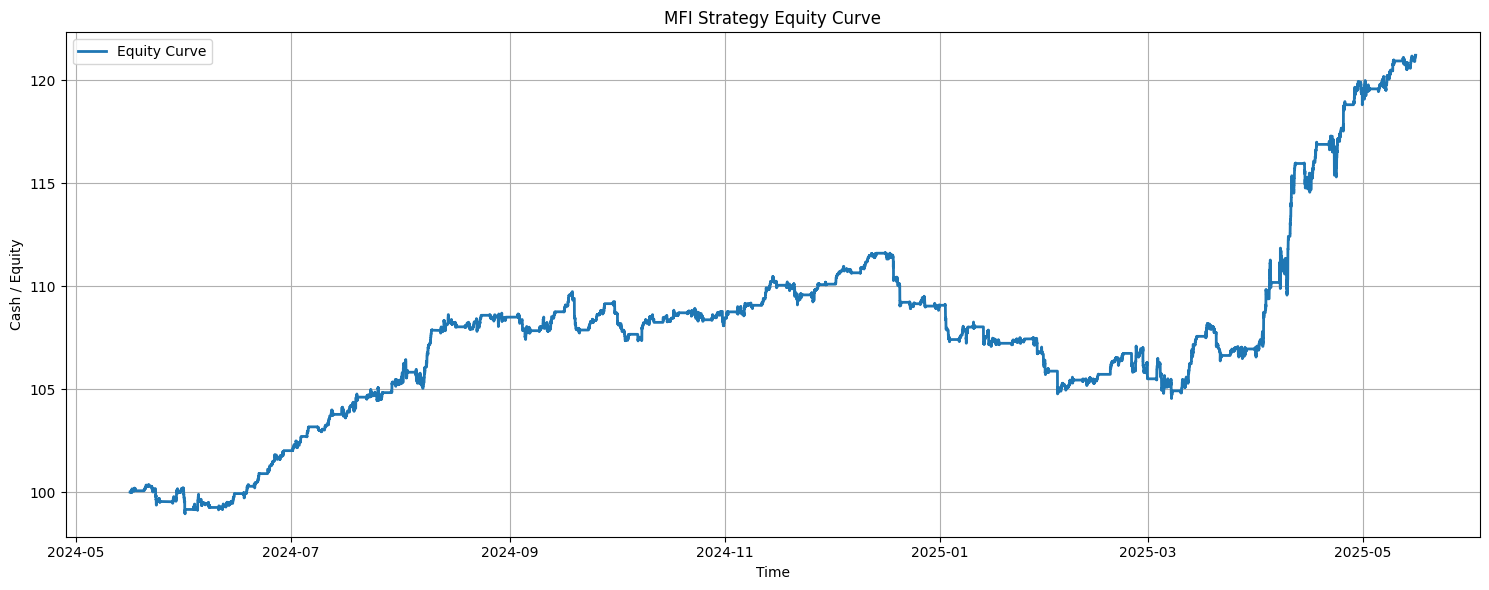

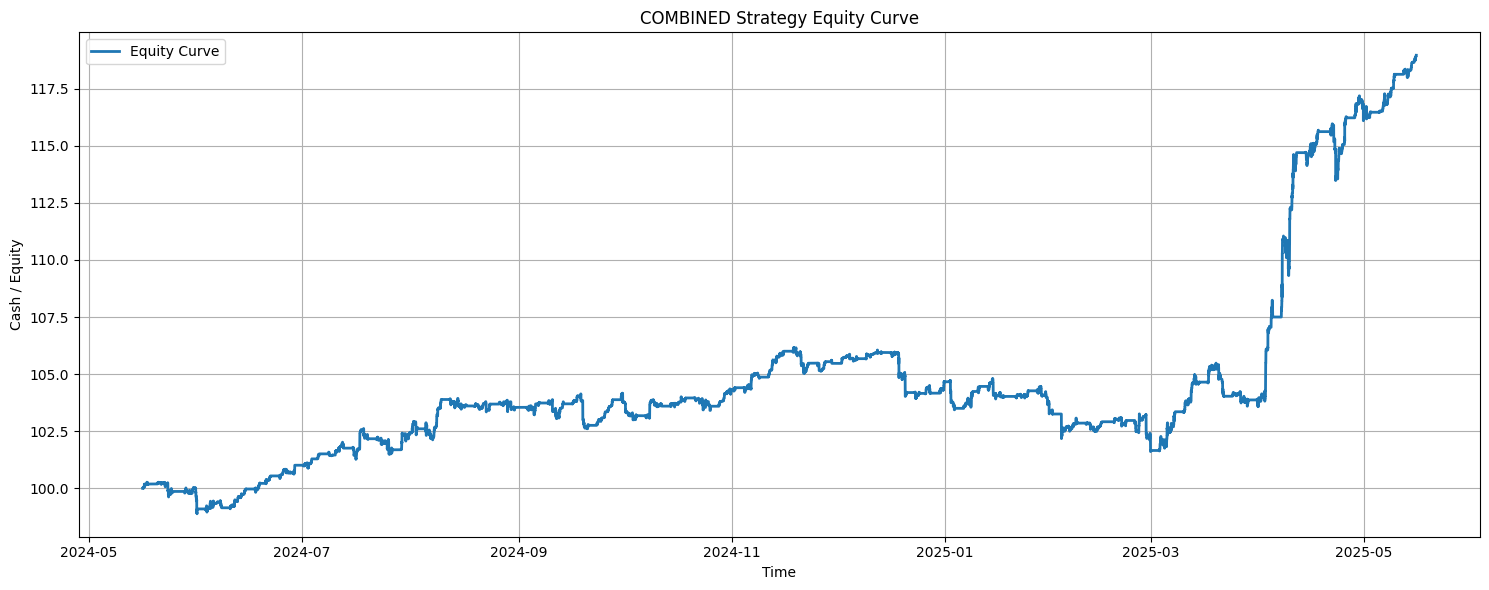

{'error': 'No completed buy/sell pairs found.'}
{'error': 'No completed buy/sell pairs found.'}
{'error': 'No completed buy/sell pairs found.'}


In [5]:
df = get_stock_data("SPY", "2024-05-16", "2025-05-16", "Minute", 1)

# RSI
signals = generate_signals_rsi(df)
equity_rsi, trade_log_rsi = backtest(signals, initial_cash=100)

# MFI
signals = generate_signals_mfi(df)
equity_mfi, trade_log_mfi = backtest(signals, initial_cash=100)

# Combined
signals = generate_combined_signal(df)
equity_combined, trade_log_combined = backtest(signals, initial_cash=100)

plot_equity_curve(equity_rsi, equity_mfi, equity_combined)
print(evaluate_trades(trade_log_rsi))
print(evaluate_trades(trade_log_mfi))
print(evaluate_trades(trade_log_combined))

TO DO:
Formal regression model

### High/Low Sweep

##### Extra Functions

In [6]:
def get_session_high_low(df, session_start, session_end):
    session_data = df.between_time(session_start, session_end)
    high = session_data['high'].max()
    low = session_data['low'].min()
    return high, low

def is_sweep(current_price, previous_high, previous_low):
    return current_price > previous_high or current_price < previous_low

asian_high, asian_low = get_session_high_low(df, "20:00", "04:00")
london_high, london_low = get_session_high_low(df, "04:00", "09:30")
nyc_high, nyc_low = get_session_high_low(df, "09:30", "13:00")


def detect_bos(df):
    bos_points = []
    for i in range(2, len(df)):
        prev = df.iloc[i - 1]
        curr = df.iloc[i]
        if curr['high'] > prev['high'] and curr['low'] > prev['low']:
            bos_points.append((df.index[i], 'bullish'))
        elif curr['low'] < prev['low'] and curr['high'] < prev['high']:
            bos_points.append((df.index[i], 'bearish'))
    return bos_points

def get_fib_retrace_entry(df, leg_start_time, leg_end_time):
    leg_df = df.loc[leg_start_time:leg_end_time]
    high = leg_df['high'].max()
    low = leg_df['low'].min()
    fib_50 = (high + low) / 2
    for i in range(len(df)):
        if abs(df['close'].iloc[i] - fib_50) / fib_50 < 0.001:  # within 0.1%
            return df.index[i]
    return None


##### Highs/Lows confluence

In [7]:
def generate_sweep_signals(df, session_start="00:00", session_end="23:59"):
    """
    Sweep strategy:
    - If previous session high is swept, go SHORT.
    - If previous session low is swept, go LONG.
    Works on 15-minute data.
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)  # Ensure datetime index
    df['signal'] = 0

    previous_high = None
    previous_low = None
    last_session_date = None

    for i in range(1, len(df)):
        current_time = df.index[i]
        current_date = current_time.date()

        if i == 1:
            last_session_date = current_date
            continue

        # Start new session if the day changes
        if last_session_date != current_date:
            # Define session boundaries for the previous day
            prev_day_data = df.loc[str(current_date - pd.Timedelta(days=1))]
            if not prev_day_data.empty:
                session_data = prev_day_data.between_time(session_start, session_end)
                if not session_data.empty:
                    previous_high = session_data['high'].max()
                    previous_low = session_data['low'].min()

            last_session_date = current_date

        # Entry logic — once a sweep occurs
        if previous_high and df['high'].iloc[i] > previous_high:
            df.iloc[i, df.columns.get_loc('signal')] = -1  # short signal
            previous_high = None  # avoid double counting
        elif previous_low and df['low'].iloc[i] < previous_low:
            df.iloc[i, df.columns.get_loc('signal')] = 1  # long signal
            previous_low = None

    return df[['close', 'signal']]


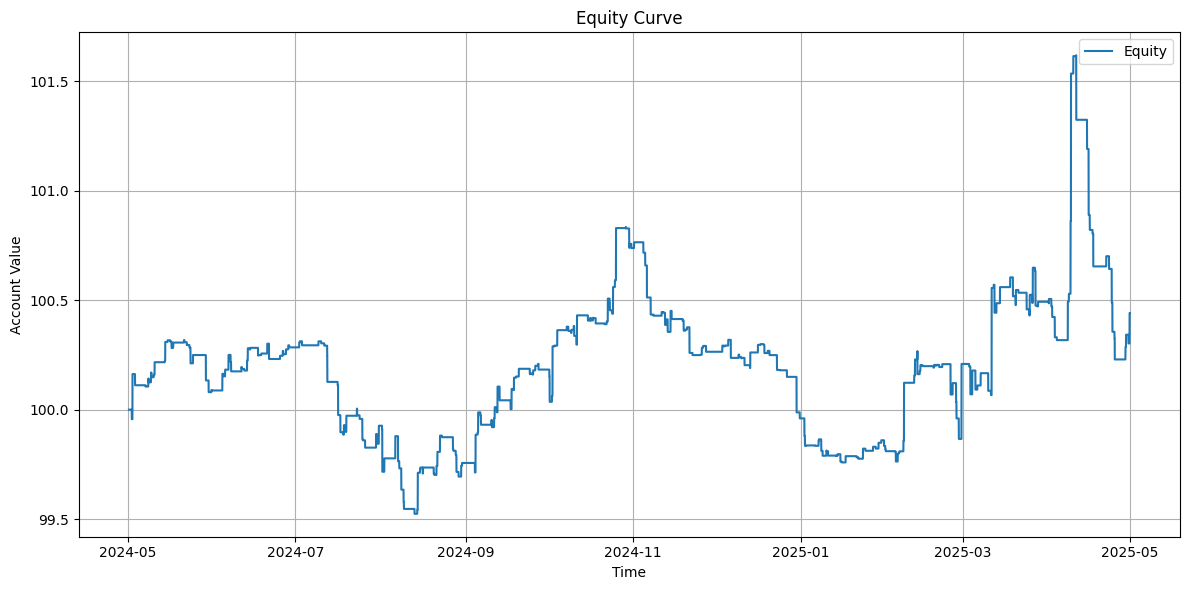

{'error': 'No completed buy/sell pairs found.'}


In [8]:
symbol = "SPY"
start_date = "2024-05-01"
end_date = "2025-05-01"
timeframe = "Minute"
mult = 5

df_15m = get_stock_data(symbol, start_date, end_date, timeframe_unit=timeframe, multiplier=mult)

# Generate sweep signals (use Asian session as example)
signal_df = generate_sweep_signals(df_15m, session_start="20:00", session_end="04:00")

# Backtest
# equity_curve, trade_log = backtest(signal_df)
equity_curve, trade_log = backtest(signal_df, initial_cash=100)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(equity_curve.index, equity_curve.values, label="Equity")
plt.title("Equity Curve")
plt.xlabel("Time")
plt.ylabel("Account Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(evaluate_trades(trade_log))


### Highs/Lows Sweep 2

In [9]:
def plot_candlesticks(df, symbol: str, signal_df=None):
    fig, ax1 = plt.subplots(1, 1, figsize=(14, 9))

    # Prepare OHLC data
    quotes = []
    for timestamp, row in df.iterrows():
        quotes.append((
            mdates.date2num(timestamp),
            row['open'],
            row['high'],
            row['low'],
            row['close']
        ))

    # Plot candles
    candlestick_ohlc(ax1, quotes, width=0.0007, colorup='green', colordown='red', alpha=0.8)

    # Plot signals if provided
    if signal_df is not None:
        for timestamp, row in signal_df.iterrows():
            if row['signal'] == 1:  # long signal
                ax1.plot(mdates.date2num(timestamp), row['close'], marker='^', color='green', markersize=10, label='Buy Signal' if 'Buy Signal' not in ax1.get_legend_handles_labels()[1] else "")
            elif row['signal'] == -1:  # short signal
                ax1.plot(mdates.date2num(timestamp), row['close'], marker='v', color='red', markersize=10, label='Sell Signal' if 'Sell Signal' not in ax1.get_legend_handles_labels()[1] else "")

    ax1.set_title(f'{symbol} Candlestick Chart with Signals')
    ax1.set_ylabel('Price')
    ax1.grid(True)
    ax1.legend()
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


In [10]:
def plot_candlesticks_with_trades(df, symbol: str, trade_log=None, show_pnl_labels=False):
    df = df.copy()
    df.index = pd.to_datetime(df.index)

    fig, ax1 = plt.subplots(1, 1, figsize=(14, 9))

    # Prepare OHLC data
    quotes = []
    for timestamp, row in df.iterrows():
        quotes.append((
            mdates.date2num(timestamp),
            row['open'],
            row['high'],
            row['low'],
            row['close']
        ))

    # Plot candlesticks
    candlestick_ohlc(ax1, quotes, width=0.0007, colorup='green', colordown='red', alpha=0.8)

    # Plot trades
    if trade_log:
        for i in range(0, len(trade_log) - 1, 2):
            entry = trade_log[i]
            exit_ = trade_log[i + 1]

            if entry['action'] == 'entry' and exit_['action'] == 'exit':
                entry_time = mdates.date2num(entry['timestamp'])
                exit_time = mdates.date2num(exit_['timestamp'])
                entry_price = entry['entry_price']
                exit_price = exit_['exit_price']
                pnl = exit_['pnl']
                side = entry['side']

                # Color and marker
                color = 'green' if pnl >= 0 else 'red'
                entry_marker = '^' if side == 'long' else 'v'

                # Plot entry
                ax1.plot(entry_time, entry_price, marker=entry_marker, color='blue', markersize=10, label='Entry' if i == 0 else "")

                # Plot exit
                ax1.plot(exit_time, exit_price, marker='x', color='black', markersize=10, label='Exit' if i == 0 else "")

                # Line between entry and exit
                ax1.plot([entry_time, exit_time], [entry_price, exit_price], color=color, linewidth=2, alpha=0.6)

                # Optional PnL label
                if show_pnl_labels:
                    ax1.text(exit_time, exit_price, f'{pnl:.2f}', fontsize=9, ha='left', va='bottom', color=color)

    ax1.set_title(f'{symbol} Candlestick Chart with Trades')
    ax1.set_ylabel('Price')
    ax1.grid(True)

    # Add legend only if entries exist
    handles, labels = ax1.get_legend_handles_labels()
    if any(labels):
        ax1.legend()

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


In [11]:
def generate_multi_session_sweep(df, sessions):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df['signal'] = 0

    session_names = list(sessions.keys())
    session_high_lows = {}  # {date: {session_name: (high, low)}}

    # Step 1: Precompute all session highs/lows
    for day in df.index.normalize().unique():
        day_str = day.strftime('%Y-%m-%d')
        session_high_lows[day_str] = {}        

        for session_name, (start, end) in sessions.items():
            if start < end:
                if day_str in df.index.strftime('%Y-%m-%d'):
                    session_data = df.loc[day_str].between_time(start, end)
                else:
                    continue
            else:
                # Session crosses midnight
                next_day = (day + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
                parts = []
                if day_str in df.index.strftime('%Y-%m-%d'):
                    parts.append(df.loc[day_str].between_time(start, "23:59"))
                if next_day in df.index.strftime('%Y-%m-%d'):
                    parts.append(df.loc[next_day].between_time("00:00", end))

                if not parts:
                    continue  # skip if no valid data

                session_data = pd.concat(parts)

            if not session_data.empty:
                high = session_data['high'].max()
                low = session_data['low'].min()
                session_high_lows[day_str][session_name] = (high, low)

    # Step 2: Check for sweeps of previous session in each session
    for i in range(1, len(df)):
        timestamp = df.index[i]
        date_str = timestamp.strftime('%Y-%m-%d')
        time_str = timestamp.strftime('%H:%M')

        for s_idx in range(1, len(session_names)):
            current_session = session_names[s_idx]
            prev_session = session_names[s_idx - 1]
            start, end = sessions[current_session]

            # Check if current time is within current session
            if (start < end and start <= time_str <= end) or (start > end and (time_str >= start or time_str <= end)):
                # Get prev session high/low
                prev_day = timestamp.date()
                if current_session == "Asian":
                    prev_day = timestamp.date() - pd.Timedelta(days=1)
                prev_day_str = prev_day.strftime('%Y-%m-%d')

                if prev_day_str in session_high_lows and prev_session in session_high_lows[prev_day_str]:
                    prev_high, prev_low = session_high_lows[prev_day_str][prev_session]

                    if df['high'].iloc[i] > prev_high:
                        df.iloc[i, df.columns.get_loc('signal')] = -1  # short
                    elif df['low'].iloc[i] < prev_low:
                        df.iloc[i, df.columns.get_loc('signal')] = 1  # long

    return df[['close', 'signal']]


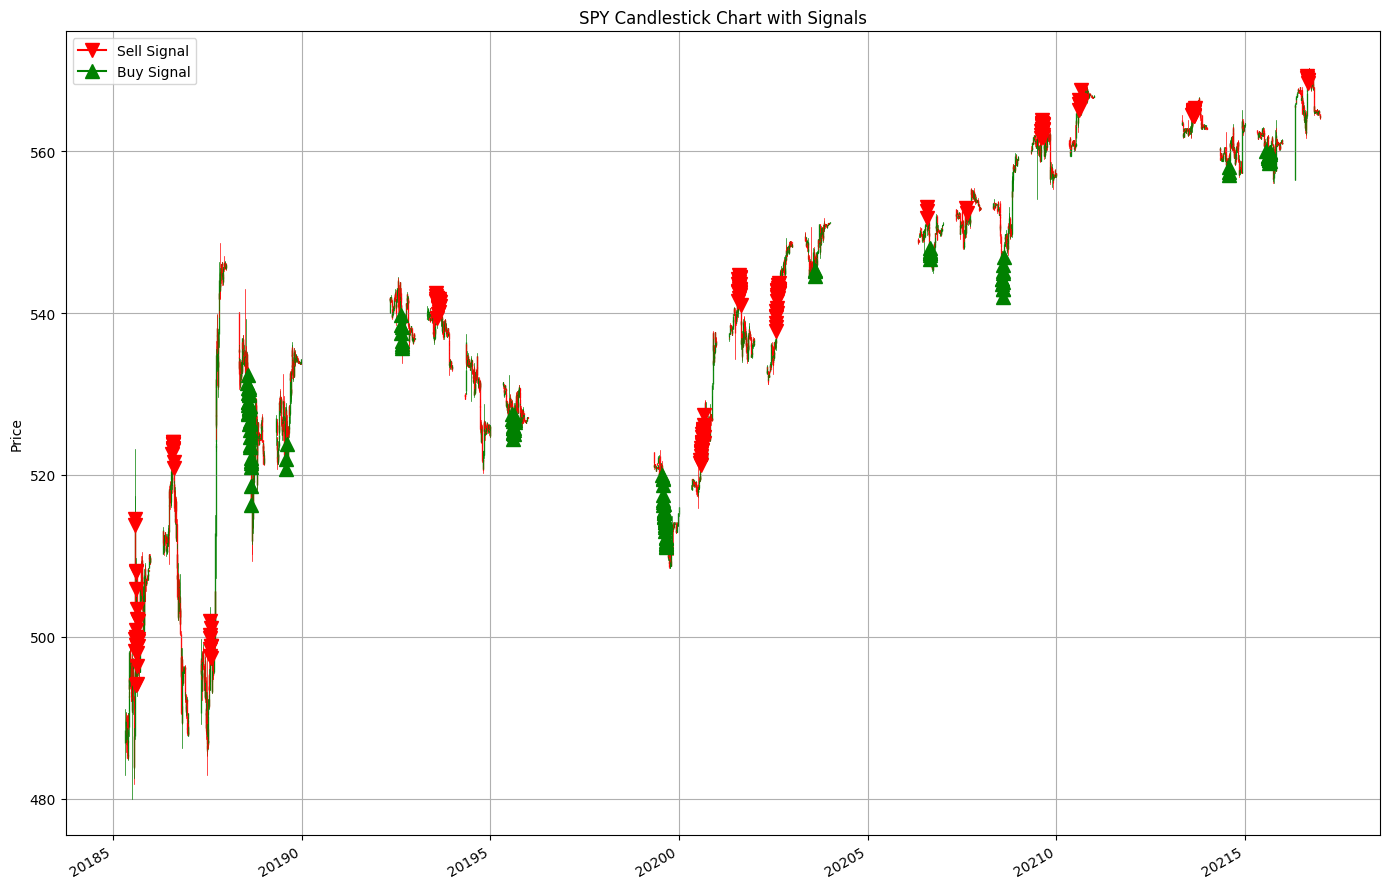

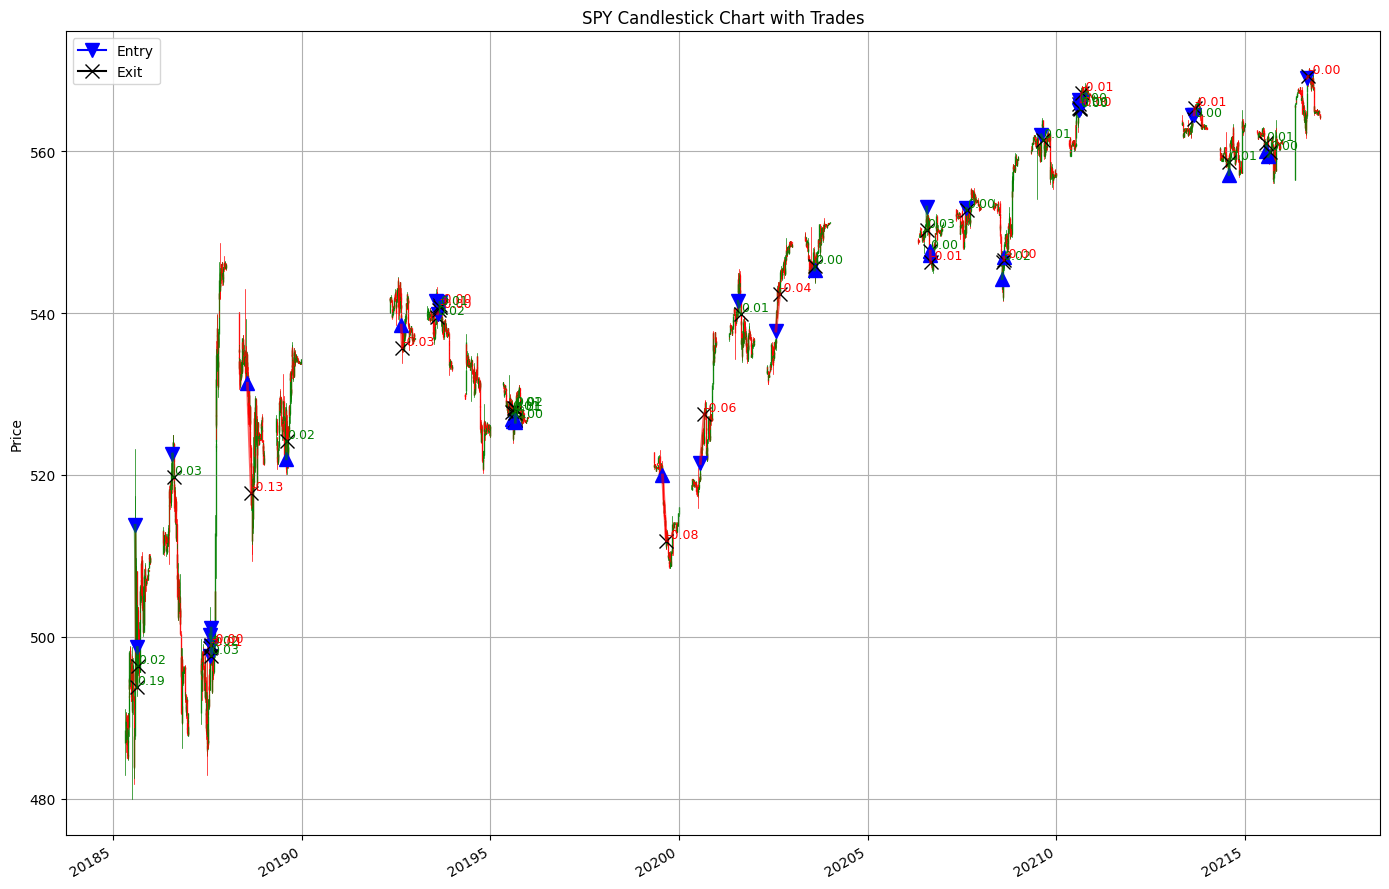

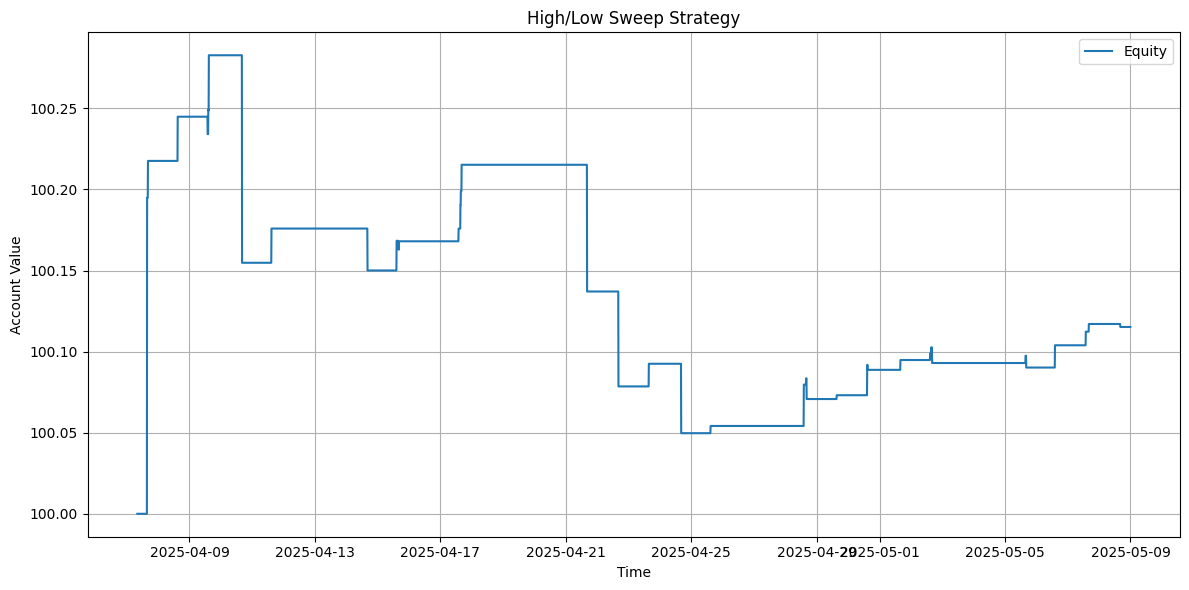

In [ ]:
sessions = {
    "Asian": ("00:00", "07:00"),
    "London": ("07:00", "13:30"),
    "NYC": ("13:30", "16:00"),
}

df = get_stock_data("SPY", "2025-04-07", "2025-05-09", timeframe_unit="Minute", multiplier=5)
signal_df = generate_multi_session_sweep(df, sessions)

# equity_curve, trade_log = backtest(signal_df, initial_cash=100)
# plot_candlesticks(df, symbol="SPY", signal_df=signal_df)

equity_curve, trade_log = backtest_signals(signal_df, initial_cash=100, risk_per_trade=0.01, leverage=5)
plot_candlesticks_with_trades(df, symbol="SPY", trade_log=trade_log, show_pnl_labels=True)

plt.figure(figsize=(12, 6))
plt.plot(equity_curve.index, equity_curve.values, label="Equity")
plt.title("High/Low Sweep Strategy")
plt.xlabel("Time")
plt.ylabel("Account Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
    